## **15 주택 가격 예측 모델 - 선형회귀**

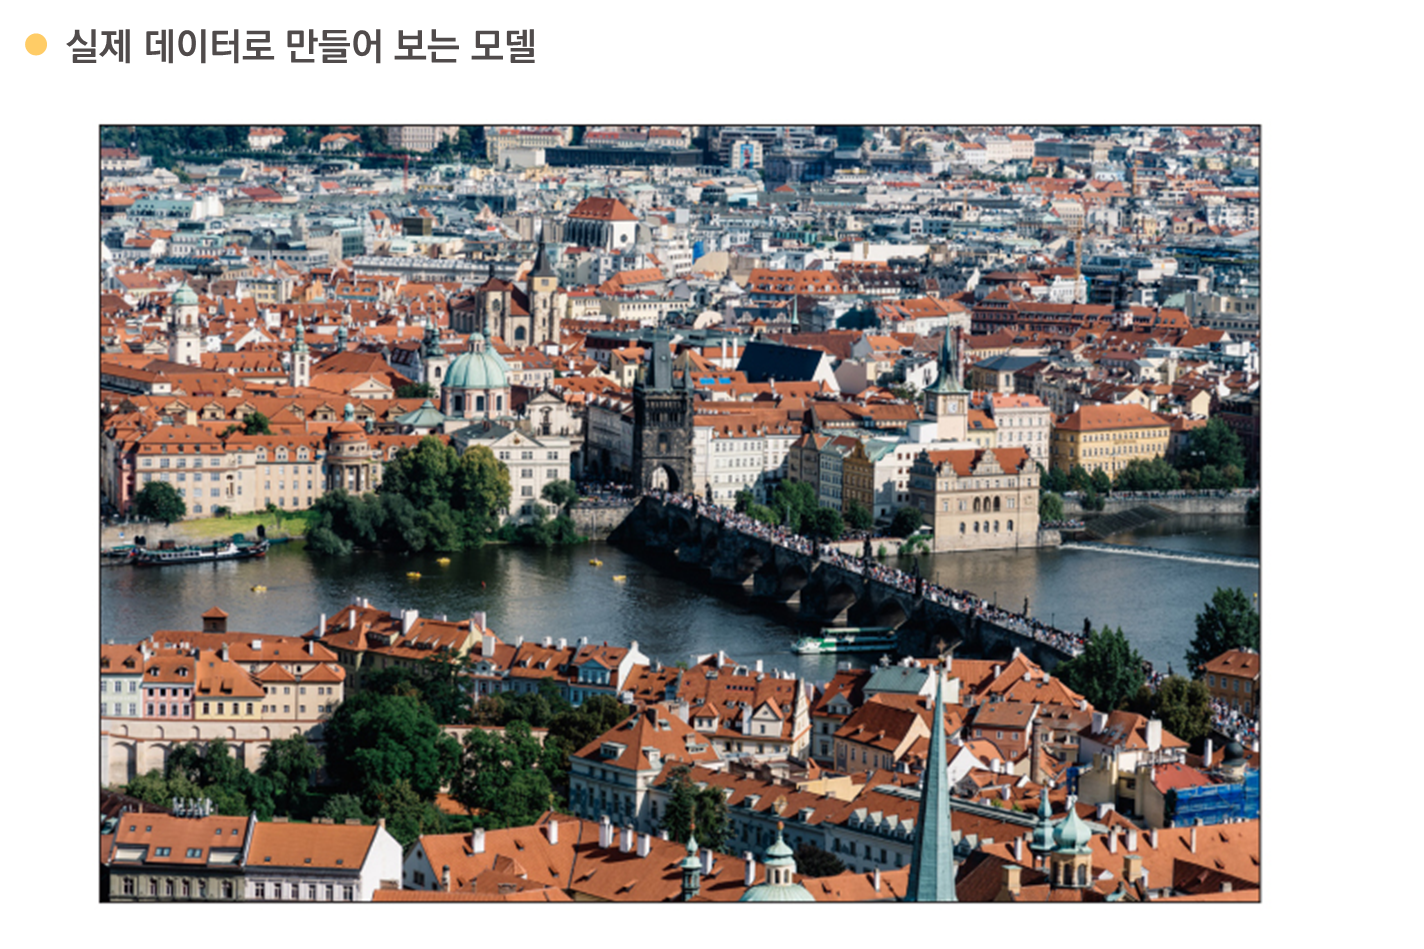

* 지금까지 한 실습은 참 또는 거짓을 맞히거나 여러 개의 보기 중 하나를 예측하는 **분류 (Classification)** 문제
* 이번에는 **수치를 예측하는 문제 (Regression:회귀)**
* 준비된 데이터는 아이오와주 에임스 지역에서 2006년부터 2010년까지 거래된 실제 부동산 판매 기록
* 주거 유형, 차고, 자재 및 환경에 관한 **80개의 서로 다른 속성** 을 이용해 집의 가격을 예측해 볼 예정
* 오랜 시간 사람이 일일이 기록하다 보니 빠진 부분도 많고, 집에 따라 어떤 항목은 범위에서 너무 벗어나 있기도 하며, 또 가격과는 관계가 없는 정보가 포함되어 있기도 함
* 실제 현장에서 만나게 되는 이런 류의 데이터를 어떻게 다루어야 하는지 이 장에서 학습해 보자


* 데이터 출처 : kaggle https://www.kaggle.com/datasets/prevek18/ames-housing-dataset

### 1. 데이터 파악하기

* 데이터 읽기

In [135]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

#데이터를 불러 옵니다.
df = pd.read_csv("./data/house_train.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


* 데이터 유형 파악

In [136]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

* 기술 통계 분석

In [137]:
df.describe()  # 숫자 타입 데이터만 나옴

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 2. 결측치, 카테고리 변수 처리하기

* 앞 장에서 다루었던 데이터와 차이점은 아직 전처리가 끝나지 않은 상태의 데이터라 측정 값이 없는 결측치가 있다는 것
* 결측치가 있는지 알아보는 함수는 isnull() 
* 결측치가 모두 몇 개인지 세어 가장 많은 것부터 순서대로 나열한 후 처음 20개만 출력하는 코드는 다음과 같음



In [138]:
# 결측치 많은 순으로 조회
# df.isnull().sum().sort_values(ascending=False).head(20)

df.isnull().sum(axis=0).sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

#### **전처리** : 카테고리 변수 처리하기

* 판다스의 get_dummies() 함수를 이용해 카테고리형 변수를 0과 1로 이루어진 변수로 바꾸어 줌


* get_dummies()에 대해 알아보기

In [139]:
df.MSZoning.value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

In [140]:
pd.get_dummies(df.MSZoning).astype('i')  # Series일 때는 컬럼명으로
# pd.get_dummies(df.MSZoning)  # Series일 때는 컬럼명으로

,C (all),FV,RH,RL,RM
0,0,0,0,1,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0
...,...,...,...,...,...
1455,0,0,0,1,0
1456,0,0,0,1,0
1457,0,0,0,1,0
1458,0,0,0,1,0


In [141]:
# MSZoning을 데이터프레임으로-> get_dummies()
# 데이터프레임에 get_dummies()를 하면 컬럼명_클래스명 으로 만들어짐

pd.get_dummies(df[['MSZoning', 'Street']]).astype('i')

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave
0,0,0,0,1,0,0,1
1,0,0,0,1,0,0,1
2,0,0,0,1,0,0,1
3,0,0,0,1,0,0,1
4,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...
1455,0,0,0,1,0,0,1
1456,0,0,0,1,0,0,1
1457,0,0,0,1,0,0,1
1458,0,0,0,1,0,0,1


In [142]:
## 카테고리형 변수를 One-hot Encoding!
df_onehot = pd.get_dummies(df)
# df_onehot.to_csv('./data/ames_onehot.csv')
df_onehot

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,True,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,True,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,True,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,True,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,False,False,False,True,False,False,False,False,True,False
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,False,False,False,True,False,False,False,False,True,False
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,False,False,False,True,False,False,False,False,True,False
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,False,False,False,True,False,False,False,False,True,False


In [143]:
## 81개 컬럼 -> 289개 컬럼으로 증가
df_onehot.columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       ...
       'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth', 'SaleType_WD',
       'SaleCondition_Abnorml', 'SaleCondition_AdjLand',
       'SaleCondition_Alloca', 'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=289)

#### 결측치 처리 : 평균값으로 채우기

* 결측치를 채워 줌
* 결측치를 채워 주는 함수는 판다스의 fillna() 
* 괄호 안에 df.mean()을 넣어 주면 평균값으로 채워 줌
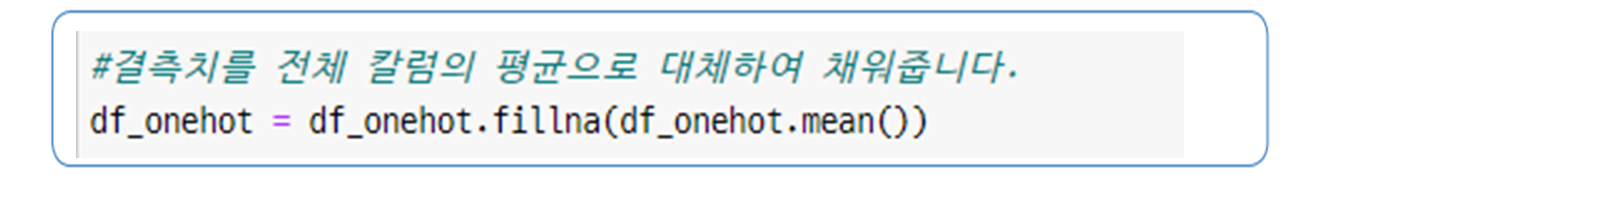

* 특정한 값으로 대체하려면 `fillna()` 함수의 괄호 안에 해당 값을 적으면 됨
* 예를 들어 결측치를 모두 0으로 바꾸려면 `fillna(0)`이 됨
* `dropna()`를 사용하면 결측치가 있는 속성을 제거
* 이때 `dropna(how='any')`는 결측치가 하나라도 있으면 삭제하라는 의미이고, `dropna(how='all')`은 모든 값이 결측치일 때 삭제하라는 의미



In [144]:
df_onehot = df_onehot.fillna(df_onehot.mean())
df_onehot

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,True,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,True,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,True,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,True,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,False,False,False,True,False,False,False,False,True,False
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,False,False,False,True,False,False,False,False,True,False
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,False,False,False,True,False,False,False,False,True,False
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,False,False,False,True,False,False,False,False,True,False


In [145]:
# 결측치 많은 순으로 조회
df_onehot.isnull().sum().sort_values(ascending=False).head(20)

Id                    0
Exterior1st_Stucco    0
BsmtFinType1_GLQ      0
BsmtFinType1_BLQ      0
BsmtFinType1_ALQ      0
BsmtExposure_No       0
BsmtExposure_Mn       0
BsmtExposure_Gd       0
BsmtExposure_Av       0
BsmtCond_TA           0
BsmtCond_Po           0
BsmtCond_Gd           0
BsmtCond_Fa           0
BsmtQual_TA           0
BsmtQual_Gd           0
BsmtQual_Fa           0
BsmtQual_Ex           0
BsmtFinType1_LwQ      0
BsmtFinType1_Rec      0
BsmtFinType1_Unf      0
dtype: int64

#### 3. 속성별 관련도 추출

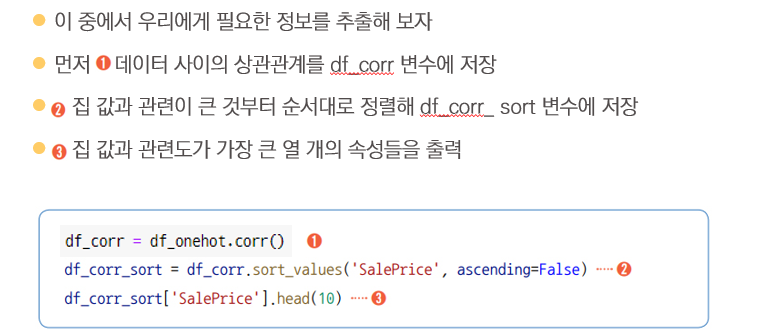

In [146]:
## 집값과 상관관계가 높은 순으로 조회 (1에 가까우면 상관도 높음, 0에 가까우면 상관도 낮음, -1에 가까우면 음의 상관관계)
df_onehot.corr().sort_values('SalePrice', ascending=False)['SalePrice'][:10]

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
BsmtQual_Ex     0.553105
TotRmsAbvGrd    0.533723
Name: SalePrice, dtype: float64

In [147]:
df_onehot.corr().sort_values('SalePrice', ascending=True)['SalePrice'][:10]

ExterQual_TA        -0.589044
KitchenQual_TA      -0.519298
BsmtQual_TA         -0.452394
GarageFinish_Unf    -0.410608
GarageType_Detchd   -0.354141
Foundation_CBlock   -0.343263
HeatingQC_TA        -0.312677
MSZoning_RM         -0.288065
LotShape_Reg        -0.267672
BsmtExposure_No     -0.263600
Name: SalePrice, dtype: float64

* 속성별 관련도 추출하기

In [148]:
# 집 값 'SalePrice'와 관련도가 가장 큰 순서로 상관도 데이터 만들기
df_corr_sort = df_onehot.corr().sort_values('SalePrice', ascending=False)['SalePrice']
df_corr_sort[:10]

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
BsmtQual_Ex     0.553105
TotRmsAbvGrd    0.533723
Name: SalePrice, dtype: float64

In [149]:
df_onehot.corr().sort_values('SalePrice', ascending=True)['SalePrice'][:10]

ExterQual_TA        -0.589044
KitchenQual_TA      -0.519298
BsmtQual_TA         -0.452394
GarageFinish_Unf    -0.410608
GarageType_Detchd   -0.354141
Foundation_CBlock   -0.343263
HeatingQC_TA        -0.312677
MSZoning_RM         -0.288065
LotShape_Reg        -0.267672
BsmtExposure_No     -0.263600
Name: SalePrice, dtype: float64

In [150]:
# 집값과 관련도가 높은 속성 이름 추출 (임의로 6개로 정함)
cols = df_corr_sort[:6].keys()
cols

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF'],
      dtype='object')

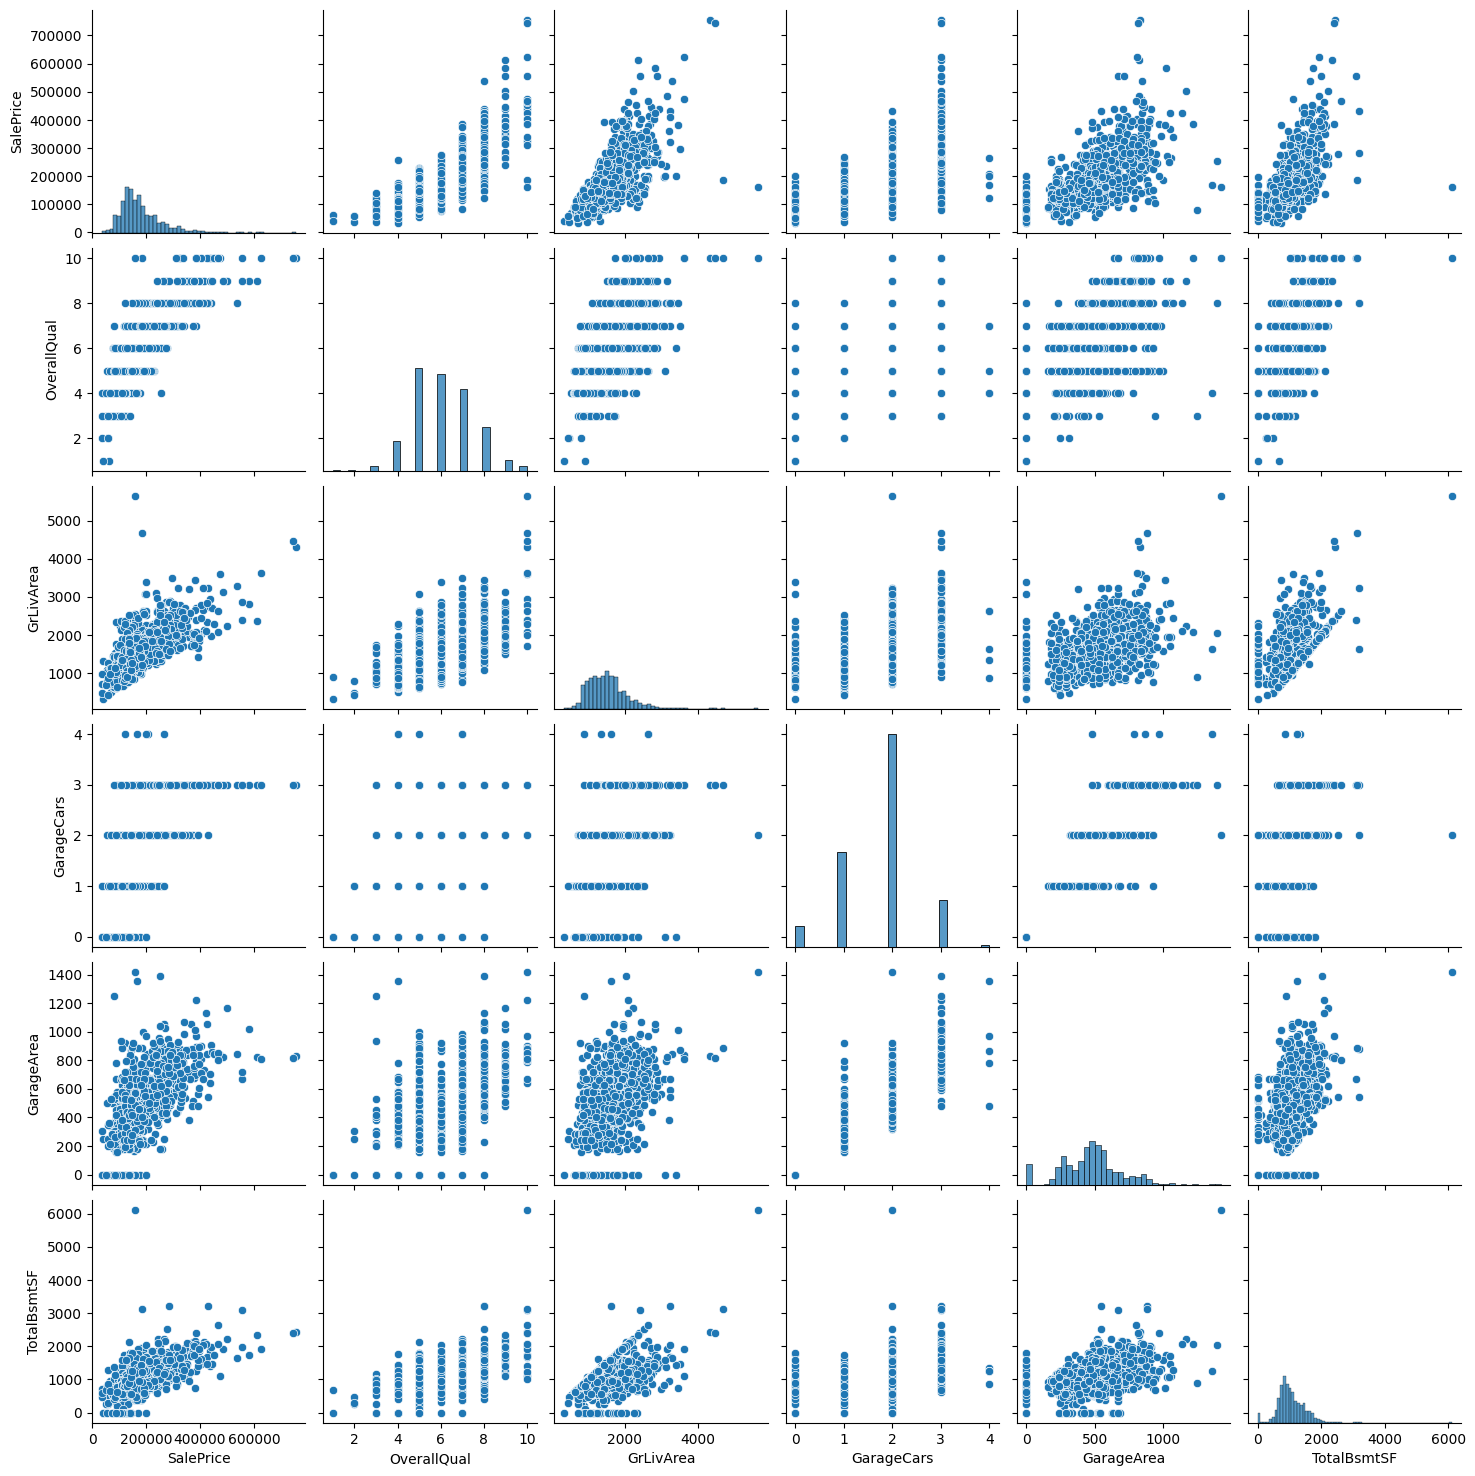

In [151]:
# 집값과 관련도가 가장 높은 속성들을 추출해서 상관도 그래프 그리기
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df_onehot[cols])
plt.show()

### 4. 주택가격 예측 모델

* 이제 앞서 구한 중요 속성을 이용해 학습셋과 테스트셋을 만들어 보자
* 집 값을 y로, 나머지 열을 X_train_pre로 저장한 후 전체의 80%를 학습셋으로, 20%를 테스트셋으로 지정


In [152]:
cols

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF'],
      dtype='object')

In [153]:
df_onehot[cols[1:]]

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF
0,7,1710,2,548,856
1,6,1262,2,460,1262
2,7,1786,2,608,920
3,7,1717,3,642,756
4,8,2198,3,836,1145
...,...,...,...,...,...
1455,6,1647,2,460,953
1456,6,2073,2,500,1542
1457,7,2340,1,252,1152
1458,5,1078,1,240,1078


In [154]:
#집 값을 제외한 나머지 열을 저장합니다. 
cols_train = ['OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF']
X_train_pre = df_onehot[cols_train]
X_train_pre

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF
0,7,1710,2,548,856
1,6,1262,2,460,1262
2,7,1786,2,608,920
3,7,1717,3,642,756
4,8,2198,3,836,1145
...,...,...,...,...,...
1455,6,1647,2,460,953
1456,6,2073,2,500,1542
1457,7,2340,1,252,1152
1458,5,1078,1,240,1078


In [155]:
#집 값을 저장합니다.
y = df_onehot['SalePrice'].values
y

array([208500, 181500, 223500, ..., 266500, 142125, 147500], dtype=int64)

In [156]:
#전체의 80%를 학습셋으로, 20%를 테스트셋으로 지정합니다.
X_train, X_test, y_train, y_test = train_test_split(X_train_pre, y, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1168, 5), (292, 5), (1168,), (292,))

* 모델 설계

In [157]:
#모델의 구조를 설정합니다.
model = Sequential()
model.add(Dense(10, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1))    # 회귀(Regression) -> activation='linear' (기본값)
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_24 (Dense)            (None, 10)                60        
                                                                 
 dense_25 (Dense)            (None, 30)                330       
                                                                 
 dense_26 (Dense)            (None, 10)                310       
                                                                 
 dense_27 (Dense)            (None, 1)                 11        
                                                                 
Total params: 711
Trainable params: 711
Non-trainable params: 0
_________________________________________________________________


* 모델 Compile - optimizer, loss 함수 설정

In [158]:
#모델을 실행합니다.
model.compile(optimizer ='adam', loss = 'mean_squared_error')  # Regression 문제에서는 mse
# model.compile(optimizer ='adam', loss = 'mse')


* 콜백 함수 정의

In [159]:
# 20회 이상 결과가 향상되지 않으면 자동으로 중단되게끔 합니다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=20)

# 모델의 이름을 정합니다.
modelpath="./data/model/house_model.keras"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', 
                               verbose=1, save_best_only=True)

* 모델 학습 : validation_split, 콜백 함수, epochs 등 지정

In [160]:
#실행 관련 설정을 하는 부분입니다. 전체의 20%를 검증셋으로 설정합니다. 
history = model.fit(X_train, y_train, validation_split=0.25, epochs=2000, verbose=0,
                    batch_size=32, callbacks=[early_stopping_callback, checkpointer])


Epoch 1: val_loss improved from inf to 39074709504.00000, saving model to ./data/model\house_model.keras

Epoch 2: val_loss improved from 39074709504.00000 to 38831013888.00000, saving model to ./data/model\house_model.keras

Epoch 3: val_loss improved from 38831013888.00000 to 38239617024.00000, saving model to ./data/model\house_model.keras

Epoch 4: val_loss improved from 38239617024.00000 to 36791640064.00000, saving model to ./data/model\house_model.keras

Epoch 5: val_loss improved from 36791640064.00000 to 33950058496.00000, saving model to ./data/model\house_model.keras

Epoch 6: val_loss improved from 33950058496.00000 to 28764915712.00000, saving model to ./data/model\house_model.keras

Epoch 7: val_loss improved from 28764915712.00000 to 20518795264.00000, saving model to ./data/model\house_model.keras

Epoch 8: val_loss improved from 20518795264.00000 to 10783776768.00000, saving model to ./data/model\house_model.keras

Epoch 9: val_loss improved from 10783776768.00000 to 

* 학습 과정 시각화

In [161]:
import pandas as pd
df_history = pd.DataFrame(history.history)
df_history

,loss,val_loss
0,3.881030e+10,3.907471e+10
1,3.860652e+10,3.883101e+10
2,3.823990e+10,3.823962e+10
3,3.727399e+10,3.679164e+10
4,3.528664e+10,3.395006e+10
5,3.141217e+10,2.876492e+10
6,2.480680e+10,2.051880e+10
7,1.563028e+10,1.078378e+10
8,6.997160e+09,4.026904e+09
9,2.770643e+09,2.335966e+09


<Axes: >

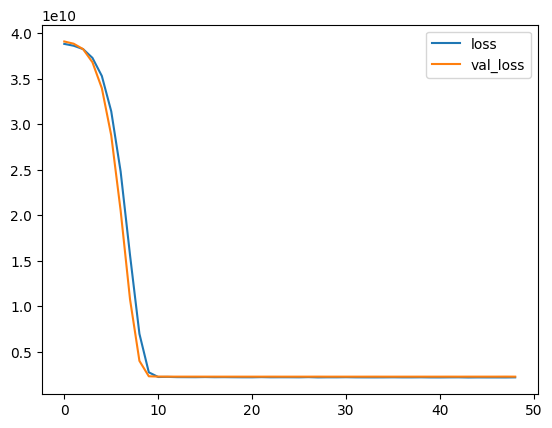

In [162]:
df_history.plot()

* 주택 가격 예측해 보기
    학습 결과를 시각화하기 위해 예측 값과 실제 값, 실행 번호가 들어갈 빈 리스트를 만들고 25개의 샘플로부터 얻은 결과를 채워 넣겠음


In [163]:
# 예측 값과 실제 값, 실행 번호가 들어갈 빈 리스트를 만듭니다.
real_prices =[]
pred_prices = []
X_num = []

# 25개의 샘플을 뽑아 실제 값, 예측 값을 출력해 봅니다. 
n_iter = 0
Y_prediction = model.predict(X_test).flatten()
for i in range(25):
    real = y_test[i]
    prediction = Y_prediction[i]
    print("실제가격: {:.2f}, 예상가격: {:.2f}".format(real, prediction))
    real_prices.append(real)
    pred_prices.append(prediction)
    n_iter = n_iter + 1
    X_num.append(n_iter)

10/10 [==============================] - 0s 2ms/step
실제가격: 158900.00, 예상가격: 153557.38
실제가격: 179000.00, 예상가격: 130319.16
실제가격: 297000.00, 예상가격: 254703.38
실제가격: 199900.00, 예상가격: 182283.80
실제가격: 127000.00, 예상가격: 135891.47
실제가격: 156000.00, 예상가격: 137293.23
실제가격: 184900.00, 예상가격: 175566.30
실제가격: 215000.00, 예상가격: 196512.27
실제가격: 324000.00, 예상가격: 226109.31
실제가격: 60000.00, 예상가격: 61892.46
실제가격: 155000.00, 예상가격: 185288.69
실제가격: 161500.00, 예상가격: 185218.95
실제가격: 140000.00, 예상가격: 172203.28
실제가격: 136905.00, 예상가격: 226081.36
실제가격: 200500.00, 예상가격: 264086.22
실제가격: 116000.00, 예상가격: 136087.09
실제가격: 119500.00, 예상가격: 126580.23
실제가격: 129000.00, 예상가격: 153800.55
실제가격: 55993.00, 예상가격: 131665.42
실제가격: 163900.00, 예상가격: 141970.92
실제가격: 318000.00, 예상가격: 265483.78
실제가격: 137000.00, 예상가격: 136540.42
실제가격: 85400.00, 예상가격: 105659.97
실제가격: 200500.00, 예상가격: 184689.14
실제가격: 194700.00, 예상가격: 186216.83


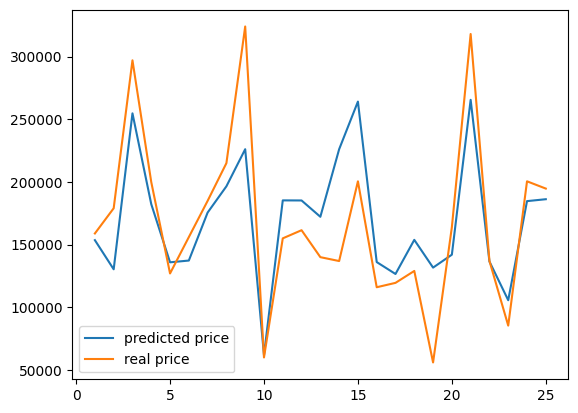

In [164]:
#그래프를 통해 샘플로 뽑은 25개의 값을 비교해 봅니다.

plt.plot(X_num, pred_prices, label='predicted price')
plt.plot(X_num, real_prices, label='real price')
plt.legend()
plt.show()

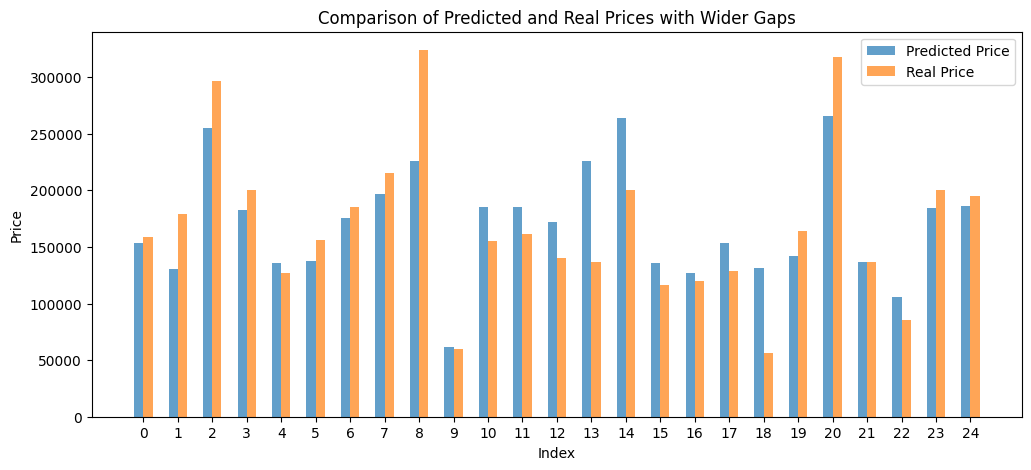

In [165]:
## 막대 그래프로 데이터 비교 그리기
import numpy as np
import matplotlib.pyplot as plt

# 막대 너비 설정
bar_width = 0.4

# X_num을 배열로 변환하고 간격을 넓힘
X_num = np.arange(len(pred_prices)) * 1.5  # 간격을 기존보다 벌림

plt.figure(figsize=(12, 5))
plt.bar(X_num - bar_width/2, pred_prices, width=bar_width, alpha=0.7, label='Predicted Price')
plt.bar(X_num + bar_width/2, real_prices, width=bar_width, alpha=0.7, label='Real Price')

plt.xticks(X_num, labels=[str(i) for i in range(len(X_num))])  # X축 눈금 설정
plt.legend()
plt.xlabel("Index")
plt.ylabel("Price")
plt.title("Comparison of Predicted and Real Prices with Wider Gaps")
plt.show()


### 실제 가격과 예상가격을 scatter plot으로 찍어보자

46/46 [==============================] - 0s 3ms/step


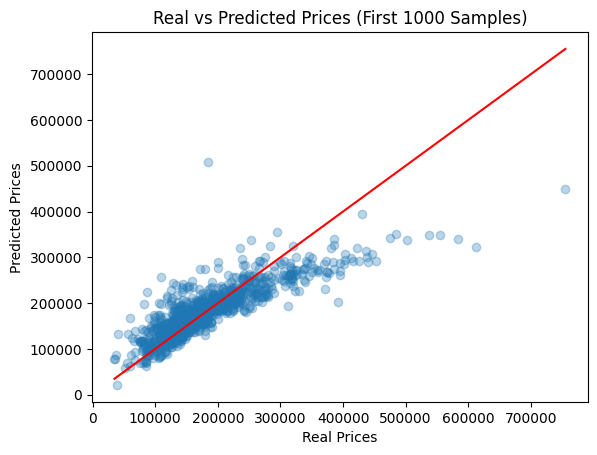

In [166]:
Y_prediction = model.predict(X_train_pre).flatten()
plt.scatter(y[:1000], Y_prediction[:1000], alpha=0.3)
plt.plot([y[:1000].min(), y[:1000].max()], [y[:1000].min(), y[:1000].max()], c="r")
plt.xlabel("Real Prices")
plt.ylabel("Predicted Prices")
plt.title("Real vs Predicted Prices (First 1000 Samples)")
plt.show()

In [167]:
## SalePrice를 제외한 5개 컬럼을 X 데이터로, SalePrice 컬럼은 y데이터로 설정
X_train_pre = df_onehot[cols[1:]]
y = df_onehot['SalePrice'].values
X_train_pre

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF
0,7,1710,2,548,856
1,6,1262,2,460,1262
2,7,1786,2,608,920
3,7,1717,3,642,756
4,8,2198,3,836,1145
...,...,...,...,...,...
1455,6,1647,2,460,953
1456,6,2073,2,500,1542
1457,7,2340,1,252,1152
1458,5,1078,1,240,1078


In [168]:
y

array([208500, 181500, 223500, ..., 266500, 142125, 147500], dtype=int64)

In [169]:
# 모델의 구조 설정
model = Sequential()
model.add(Dense(10, input_dim=5, activation='relu'))
model.add(Dense(20, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(1))     #################??? Linear Regression문제!!! -> activation 없이(항등함수)
model.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_28 (Dense)            (None, 10)                60        
                                                                 
 dense_29 (Dense)            (None, 20)                220       
                                                                 
 dense_30 (Dense)            (None, 30)                630       
                                                                 
 dense_31 (Dense)            (None, 1)                 31        
                                                                 
Total params: 941
Trainable params: 941
Non-trainable params: 0
_________________________________________________________________


In [170]:
## 모델로... 가격 추정...
N = 100
model.predict(X_train_pre[:N]).flatten()  # shape를 펼쳐서 y와 같게!

4/4 [==============================] - 0s 5ms/step


array([110.27945 ,  55.953144, 124.41893 , 133.70839 , 177.5733  ,
        96.04584 ,  76.05238 ,  80.26152 ,  83.77811 ,  39.52338 ,
        46.40108 , 146.98724 ,  41.602913, 114.84018 ,  49.703125,
        79.5029  ,  58.941216,  83.77159 ,  74.91539 ,  51.091625,
       180.42589 ,  47.049652,  72.51941 ,  78.28124 ,  40.821297,
       124.17055 ,  80.15229 ,  91.21684 ,  58.682938,  28.587051,
        36.662975,  44.36381 ,  56.791084,  70.29843 ,  68.57213 ,
       135.32909 ,  94.370926,  58.89761 ,  39.22441 , -44.611877,
        61.371834,  49.298065,  73.53377 ,  39.7241  ,  44.578075,
        74.21705 , 120.67401 , 104.82119 ,  12.210411,  44.43194 ,
        69.181366,  99.19962 ,  71.97146 , 111.32993 , 109.15142 ,
        66.19397 ,  86.669426, 114.871376, 106.42325 ,  41.35866 ,
        72.92344 ,  53.251472,  59.960052,  84.42284 , 128.16013 ,
       179.92343 ,  87.33853 ,  66.26103 ,  30.214996, 123.75148 ,
        82.25481 ,  40.267723,  76.67391 ,  57.70198 ,  64.531

4/4 [==============================] - 0s 4ms/step


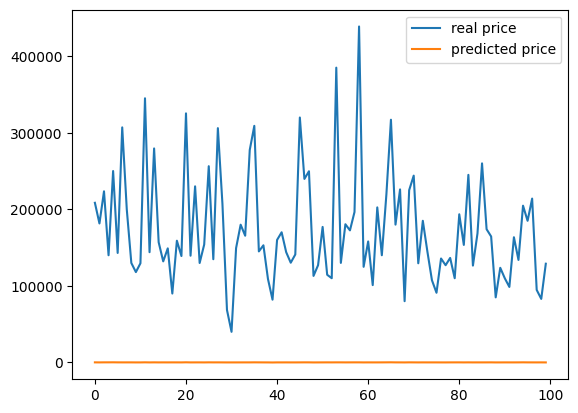

In [171]:
y_predicted = model.predict(X_train_pre[:N]).flatten()
plt.plot(range(N), y[:N], label='real price')
plt.plot(range(N), y_predicted, label='predicted price')
plt.legend()
plt.show()

In [172]:
# 예측 값과 실제 값, 실행 번호가 들어갈 빈 리스트를 만듭니다.
real_prices =[]
pred_prices = []
X_num = []

# 25개의 샘플을 뽑아 실제 값, 예측 값을 출력해 봅니다. 
n_iter = 0
Y_prediction = model.predict(X_train_pre).flatten()
for i in range(25):
    real = y[i]
    prediction = Y_prediction[i]
    print("실제가격: {:.2f}, 예상가격: {:.2f}".format(real, prediction))
    real_prices.append(real)
    pred_prices.append(prediction)
    n_iter = n_iter + 1
    X_num.append(n_iter)

46/46 [==============================] - 0s 2ms/step
실제가격: 208500.00, 예상가격: 110.28
실제가격: 181500.00, 예상가격: 55.95
실제가격: 223500.00, 예상가격: 124.42
실제가격: 140000.00, 예상가격: 133.71
실제가격: 250000.00, 예상가격: 177.57
실제가격: 143000.00, 예상가격: 96.05
실제가격: 307000.00, 예상가격: 76.05
실제가격: 200000.00, 예상가격: 80.26
실제가격: 129900.00, 예상가격: 83.78
실제가격: 118000.00, 예상가격: 39.52
실제가격: 129500.00, 예상가격: 46.40
실제가격: 345000.00, 예상가격: 146.99
실제가격: 144000.00, 예상가격: 41.60
실제가격: 279500.00, 예상가격: 114.84
실제가격: 157000.00, 예상가격: 49.70
실제가격: 132000.00, 예상가격: 79.50
실제가격: 149000.00, 예상가격: 58.94
실제가격: 90000.00, 예상가격: 83.77
실제가격: 159000.00, 예상가격: 74.92
실제가격: 139000.00, 예상가격: 51.09
실제가격: 325300.00, 예상가격: 180.43
실제가격: 139400.00, 예상가격: 47.05
실제가격: 230000.00, 예상가격: 72.52
실제가격: 129900.00, 예상가격: 78.28
실제가격: 154000.00, 예상가격: 40.82
